## **Import & Setup**

In [ ]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../src')
from pipeline import make_itemcf_backend, make_pipeline_score_fn
from preferences import PREFERENCE_TERMS, neighborhoods_satisfying
from llm import call_llm
from extract import make_extractor

We see that the features are overlapping, essentially function as 1 axes/dimension...

The queries that actually prove preference-responsiveness are Conflicting queries ("peripheral," "large/spacious," "away from the centre")

## **Query Set Generation**

We will use a set of queries to demonstrate the inability of CF to capture specific preferances (obviously, pure CF yet).
In this section we evaluate **the ability to fetch candidates based on preferances** only !

In [2]:
def make_query(nace, text, terms):
    """Build a benchmark record. `terms` = the hard constraints the query expresses.
    Ground truth is generated automatically from them."""
    terms = set(terms)
    return {
        'nace': nace,
        'text': text,
        'true_terms': terms,
        'ground_truth': neighborhoods_satisfying(terms),
    }

In [3]:
# CF tends to suggest central locations by default. In order to demonstrate the inability to capture preferances, 
# we need to include a good number of queries that explicitly pull against this tendency, otherwise the benchmark will be too easy 
# (CF will do well even without understanding the preferences).

benchmark = [
    # --- Aligned / control (CF already roughly satisfies these) --- 
    make_query(56.1,  "I want to open a restaurant right in the city centre", {'central'}),
    make_query(47.71, "a clothing boutique near campus", {'near_university'}),
    make_query(56.3,  "a café right by the sea", {'coastal'}),
    make_query(86.22, "a clinic in the heart of town, easy for everyone to reach", {'central'}),
    make_query(56.3,  "a coffee shop near the beach", {'coastal'}),
    make_query(56.3,  "a local bar right by a university", {'near_university'}),
    make_query(47.71, "a clothing shop in the center of the city near the seafront", {'central', 'coastal'}),
    make_query(56.1,  "a place to dine right by the coast", {'coastal'}),
    make_query(56.3,  "a night club in the middle of the town", {'central'}),
    make_query(86.22, "a doctor's office in the city center", {'central'}),

    # --- Conflicting / high-value (force an override against the central pull) --- 
    make_query(56.1,  "somewhere out in the countryside, away from the crowds", {'peripheral'}),
    make_query(47.59, "I'd rather avoid the busy downtown — somewhere on the outskirts", {'peripheral'}),
    make_query(86.22, "a quiet practice in one of the outer villages", {'peripheral'}),
    make_query(47.59, "I need a big plot with room to grow, away from the centre", {'peripheral', 'large_area'}),
    make_query(47.59, "a sprawling store in one of the larger, more open districts", {'large_area'}),
    make_query(47.65, "a toy shop out in a residential suburb, away from the centre", {'peripheral'}),  # long-tail + peripheral

    # --- more pure peripheral (vary the phrasing — this is where parsing actually matters) ---
    make_query(45.2,  "a workshop on the outskirts, away from the congestion", {'peripheral'}),
    make_query(56.3,  "a low-key bar somewhere off the beaten track", {'peripheral'}),
    make_query(86.9,  "a wellness centre somewhere calm, removed from the city noise", {'peripheral'}),
    make_query(69.2,  "an accounting office — doesn't need to be central, the fringe is fine", {'peripheral'}),
    make_query(56.1,  "not in the centre — a destination spot people drive out to", {'peripheral'}),
    make_query(47.71, "a shop out where the rents are low, on the city's edge", {'peripheral'}),
    make_query(86.22, "a practice serving the outlying communities, well away from downtown", {'peripheral'}),

    # --- pure large_area (district/footprint cues, space-hungry classes) ---
    make_query(45.2,  "a big lot with room for a yard and parking, in one of the larger districts", {'large_area'}),
    make_query(46.22, "a wholesale yard needing plenty of land, in a large open area", {'large_area'}),

    # --- peripheral + large_area (the outer-rural overlap) ---
    make_query(46.22, "a plant and flower wholesaler — needs a big plot, well outside the city", {'peripheral', 'large_area'}),
    make_query(45.2,  "a large vehicle workshop with a yard, out in the rural outskirts", {'peripheral', 'large_area'}),
    make_query(56.1,  "a countryside taverna with gardens and lots of land", {'peripheral', 'large_area'}),

    # --- COLD-START STRESS (your highest-value queries) — slot your real single-neighbourhood code ---
    make_query(95.12, "the first place of its kind out in the outer villages", {'peripheral'}),
    make_query(42.11, "somewhere in the periphery where there's nothing like it yet", {'peripheral'}),

]

## **Load Data & CF Backend**

In [6]:
train_matrix = pd.read_parquet('../data/train_matrix.parquet')
itemcf_backend = make_itemcf_backend(train_matrix)

# guard against KeyErrors mid-eval
missing = [q['nace'] for q in benchmark if q['nace'] not in train_matrix.index]
print('missing from train_matrix:', missing)

missing from train_matrix: []


## **Comparison Metrics**

In [7]:
K_VALUES = [1, 3, 5, 10]
CENTRAL_POLE = {'central', 'coastal', 'near_university'}

def category(q):
    return 'aligned' if q['true_terms'] <= CENTRAL_POLE else 'conflicting'

def topk(scores, k):
    finite = scores[np.isfinite(scores)]      # only neighbourhoods the system endorses
    return list(finite.nlargest(k).index)

def precision_at_k(recs, gt):
    return sum(n in gt for n in recs) / len(recs) if recs else 0.0

def eval_benchmark(score_fn_builder, benchmark, k_values=K_VALUES):
    rows = []
    for q in benchmark:
        scores = score_fn_builder(q)(q['nace'])
        row = {'category': category(q)}
        for k in k_values:
            row[f'p@{k}'] = precision_at_k(topk(scores, k), q['ground_truth'])
        rows.append(row)
    return pd.DataFrame(rows)

## **Evaluate: Oracle/CF/Hybrid (CF+LLM)**

In [8]:
def summarize(df, name):
    cols = [f'p@{k}' for k in K_VALUES]
    print(f'\n{name} — mean precision@k by query type:')
    print(df.groupby('category')[cols].mean().round(3))

In [9]:
def plot_precision(method_dfs, k=5):
    """method_dfs: {name: per-query df with 'category' + 'p@k' columns}."""
    col, cats = f'p@{k}', ['aligned', 'conflicting']
    methods = list(method_dfs)
    means = {m: method_dfs[m].groupby('category')[col].mean().reindex(cats) for m in methods}

    x, w = np.arange(len(cats)), 0.8 / len(methods)
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, m in enumerate(methods):
        ax.bar(x + i*w - 0.4 + w/2, means[m].values, w, label=m)
    ax.set_xticks(x); ax.set_xticklabels(cats)
    ax.set_ylabel(f'mean precision@{k}'); ax.set_ylim(0, 1.05)
    ax.set_title(f'Preference satisfaction by query type (precision@{k})')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

### **Oracle**

In [10]:
oracle_builder = lambda q: make_pipeline_score_fn(
    itemcf_backend, constraints={'hard': q['true_terms'], 'soft': set()}
)

oracle_df = eval_benchmark(oracle_builder, benchmark)
summarize(oracle_df, 'Oracle pipeline (true_terms -> filter)')


Oracle pipeline (true_terms -> filter) — mean precision@k by query type:
             p@1  p@3  p@5  p@10
category                        
aligned      1.0  1.0  1.0   1.0
conflicting  1.0  1.0  1.0   1.0


### **CF**

In [11]:
cf_builder = lambda q: itemcf_backend          # ignores the query entirely
cf_df     = eval_benchmark(cf_builder, benchmark)
summarize(cf_df,     'Bare ItemCF (no preference filtering)')


Bare ItemCF (no preference filtering) — mean precision@k by query type:
             p@1    p@3   p@5  p@10
category                           
aligned      0.4  0.767  0.74  0.73
conflicting  0.0  0.000  0.00  0.01


### **Hybrid (CF+LLM)**

In [12]:
extract_constraints = make_extractor(call_llm)

for q in benchmark:                                  # ~30 short calls, a couple of minutes
    q['pred_terms'] = extract_constraints(q['text'])['hard']

n_exact = sum(q['pred_terms'] == q['true_terms'] for q in benchmark)
print(f'exact match: {n_exact}/{len(benchmark)}\n')
for q in benchmark:
    ok = '✓' if q['pred_terms'] == q['true_terms'] else '✗'
    print(f"{ok}  true={sorted(q['true_terms'])}  pred={sorted(q['pred_terms'])}  | {q['text'][:45]}")

exact match: 27/30

✓  true=['central']  pred=['central']  | I want to open a restaurant right in the city
✓  true=['near_university']  pred=['near_university']  | a clothing boutique near campus
✓  true=['coastal']  pred=['coastal']  | a café right by the sea
✓  true=['central']  pred=['central']  | a clinic in the heart of town, easy for every
✓  true=['coastal']  pred=['coastal']  | a coffee shop near the beach
✓  true=['near_university']  pred=['near_university']  | a local bar right by a university
✓  true=['central', 'coastal']  pred=['central', 'coastal']  | a clothing shop in the center of the city nea
✓  true=['coastal']  pred=['coastal']  | a place to dine right by the coast
✓  true=['central']  pred=['central']  | a night club in the middle of the town
✓  true=['central']  pred=['central']  | a doctor's office in the city center
✓  true=['peripheral']  pred=['peripheral']  | somewhere out in the countryside, away from t
✓  true=['peripheral']  pred=['peripheral']  | I'd rath

In [13]:
llm_builder = lambda q: make_pipeline_score_fn(
    itemcf_backend, constraints={'hard': q['pred_terms'], 'soft': set()})

llm_df = eval_benchmark(llm_builder, benchmark)
summarize(llm_df, 'LLM pipeline (extracted terms)')


LLM pipeline (extracted terms) — mean precision@k by query type:
             p@1  p@3  p@5  p@10
category                        
aligned      1.0  1.0  1.0   1.0
conflicting  1.0  1.0  1.0   1.0


## **Comparison**

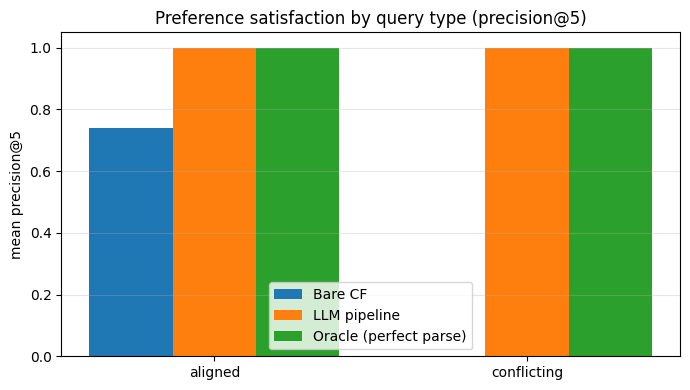

In [14]:
plot_precision({'Bare CF': cf_df, 'LLM pipeline': llm_df, 'Oracle (perfect parse)': oracle_df}, k=5)

In [16]:
def filter_coverage(pred_terms, gt):
    features = pd.read_parquet('../data/neighborhood_features.parquet')
    filtered = neighborhoods_satisfying(pred_terms) if pred_terms else set(features.index)
    return len(filtered & gt) / len(gt) if gt else 1.0

cov = pd.DataFrame([{'category': category(q),
                     'coverage': filter_coverage(q['pred_terms'], q['ground_truth'])}
                    for q in benchmark])
print(cov.groupby('category')['coverage'].mean().round(3))

category
aligned        1.000
conflicting    0.938
Name: coverage, dtype: float64


We have essentially shown the weakness of pure CF, the inability to include constrains while making recommendations (obviously since it is plain CF).
This is demonstrated by testing for 2 cases: **aligned** and **conflicting** queries.
- **aligned** --> CF 'performes' somewhat well, only due to the trend to suggest central (aligned) locations
- **conflicting** --> CF gets exposed when a user explicitly desires a peripherial (conficting) location

The next step demonstrates how the LLM can be benficial here: it is **very good at capturing preferences**, it actually matches the Oracle (ideal).

The next step is apparently to prove the other side of the coin, meaining "Why do we need a hybrid approach instead of a pure LLM?" --> I assume this may lie in the recommendation quality whose expert should be the CF.